# Introduzione

Questo notebook esplora il dataset TMDB 5000 Movies, una raccolta di dati su circa 5.000 film tratti dalla piattaforma The Movie Database. Il dataset è composto da due file CSV: `tmdb_5000_movies.csv` e `tmdb_5000_credits.csv`, uniti tramite l'identificatore univoco del film per evitare ambiguità legate a omonimie (ad esempio, Batman del 1966 e Batman del 1989).

L'obiettivo principale è condurre un'**Analisi Esplorativa dei Dati** (EDA) per comprendere la struttura, la qualità e le caratteristiche del dataset, come passo preliminare alla costruzione di un sistema di ricerca basata sul titolo dei film.

# Importazione delle librerie

Le librerie utilizzate nel codice sono:
- `ast` per leggere stringhe che sembrano liste o dizionari e trasformarle in oggetti
- `pandas` per lavorare con tabelle di dati
- `matplotlib` per la creazione di grafici statici
- `seaborn` per la creazione di grafici statistici con un'interfaccia migliore
- Il modulo `plotly.express` della libreria `plotly` che permette di creare grafici interattivi
- La funzione `Counter` dalla libreria `collections` che consente di contare occorrenze di elementi in un iterabile restituendo un dizionario

Inoltre impostiamo lo stile di seaborn su `whitegrid` per migliorarne la leggibilità e l'estetica.

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter

sns.set_theme(style="whitegrid")

# Caricamento ed esplorazione dei dataset
Carica entrambi i file **CSV** tramite **Pandas** e li unice tramite l'id univoco di ogni film. Questa operazione viene eseguita per evitare omonimie di film presenti nel database (es. Batman 1989 e Batman 1966).

Verifichiamo le dimensioni del dataset con il comando `df.shape` per vedere che quest'ultimo contine **24 colonne** e **4803 righe**.

In [2]:
df1 = pd.read_csv("data/tmdb_5000_movies.csv")
df2 = pd.read_csv("data/tmdb_5000_credits.csv")
df = pd.merge(df1, df2, left_on="id", right_on="movie_id")

df.shape

(4803, 24)

Possiamo vedere le prime 5 righe del dataset con il comando `df.head()` per iniziare a farci un'idea di come quest'ultimo è strutturato e analizzarne le varie colonne.

In [3]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


Tramite `df.info()`, invece, possiamo iniziare a vedere direttamente a schermo un riepilogo conciso del dataframe, senza restituire alcun valore.
Questo ci mostra:
- Tipo della classe (`pandas.core.frame.DataFrame`)
- RangeIndex: numero totale di righe
- Numero di colonne e relative etichette
- Non-Null Count: quanti valori non nulli sono presenti per ogni colonna per individuare dati mancanti
- Dtype: tipo di dato presente in ogni colonna
- Utilizzo della memoria del DataFrame

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

`df.describe()` ci restituisce un riepilogo statistico delle colonne numeriche del dataframe, fondamentale per l'**Analisi Esplorativa dei Dati** (**EDA**). Qui possiamo vedere diversi valori:
- `count`: Numero di valori non nulli
- `mean`: Media aritmetica
- `std`: Deviazione standard
- `min`: Valore minimo
- `25%`: Primo quartile (Q1)
- `50%`: Mediana (Q2)
- `75%`: Terzo quartile (Q3)
- `max`: Valore massimo


In [5]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989,57165.484281
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000,14629.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


Dopo aver letto diverse statistiche del nostro dataframe possiamo anche visualizzarle, andando a vedere, ad esempio, i valori mancanti per quelle colonne che ne hanno.

Questo lo facciamo andando a sommare i vari valori `null` delle colonne e filtrando per vedere solo quelli che ci interessano.
Possiamo poi metterli su un istogramma in cui verifichiamo la percentuale per ogni colonna dei valori mancanti.

Qui possiamo osservare che le colonne che presentano più valori mancanti sono `homepage` (>60%) e `tagline` (>15%).

homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64


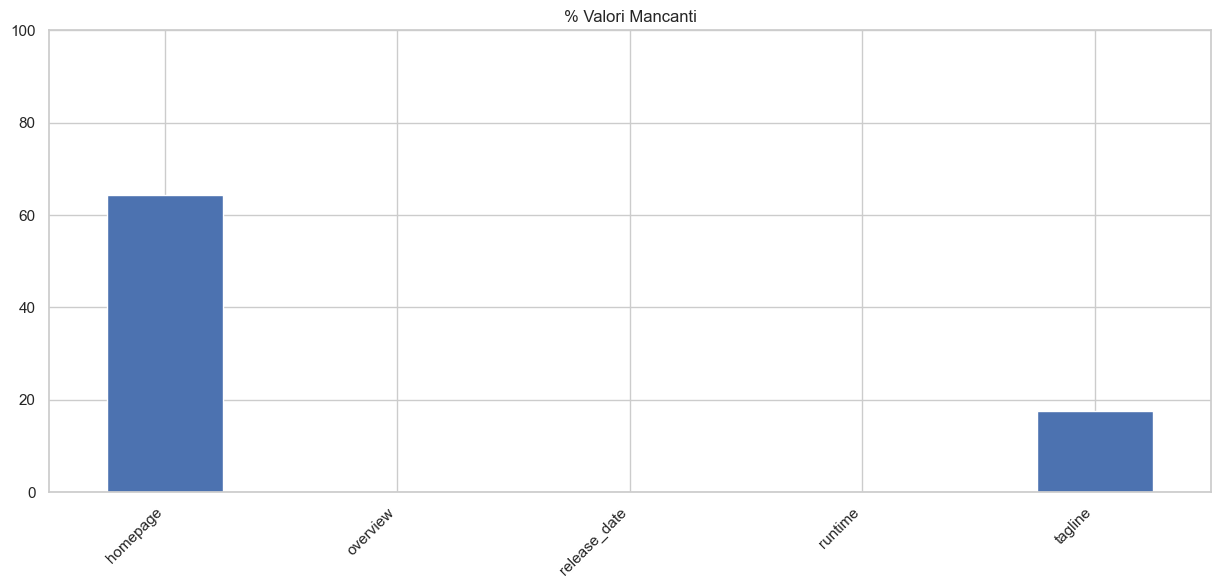

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct[missing_pct > 0].plot(kind="bar", figsize=(15, 6), title="% Valori Mancanti")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
plt.show()

Infine, possiamo verificare che all'interno del dataset non sono presenti righe duplicate tramite il comando `df.duplicated().sum()`.

In [7]:
print("Duplicati:", df.duplicated().sum())

Duplicati: 0


# Pulizia del dataset

Dopo aver visualizzato e capito come funziona il dataset possiamo finalmente passare ad una fase di pulizia in cui formattiamo le varie colonne nel formato giusto per l'analisi ed eliminiamo i valori non utili.

## Helper functions
In primis definiamo le funzioni che ci servono alla manipolazione dei dati.
#### extract_list
La funzione `extract_list` estrae i nomi da una colonna JSON-like e li riporta sotto forma di lista, con la possibilità di applicare un limite al numero di nomi che vogliamo estrarre.
#### get_director
La funzione `get_director` estrae il nome del regista dalla colonna JSON-like, in modo da non avere inutilmente tutti i membri della crew che ha lavorato al film.

In [8]:
def extract_list(text, limit = None):
    try:
        items = ast.literal_eval(text)
        names = [item["name"] for item in items]
        return names[:limit] if limit else names
    except:
        return []

def get_director(text):
    try:
        items = ast.literal_eval(text)
        for item in items:
            if item["job"] == "Director":
                return item["name"]
        return ""
    except:
        return ""

## Processing Dataset
Per processare il dataset vengono eseguite diverse operazioni in modo da pulirlo e renderlo più comodo per eseguire la vera e propria ricerca.
In primo luogo viene estratto l'anno di pubblicazione del film dal campo `release_date` in cui abbiamo una data in formato *YYYY-MM-DD* ed inserito nella colonna `year`. In questo modo possiamo condurre analisi temporali basate sugli anni di produzione dei film.

Elimino le colonne per cui non è stato rilasciato il film controllando la colonna `status` per la stringa "Released", poiché potrebbero contenere dati mancanti o inesatti.

Vengono poi eliminate tutte quelle colonne che non sono utili alla nostra analisi, ovvero: `title_y` (duplicata in seguito al merge), `tagline`, `homepage`, `movie_id` (usiamo la colonna id al suo posto), `overview` e `status`. Eliminiamo inoltre i casi in cui `runtime` non ha valore visto che, essendo solo 2, sono trascurabili.
Rinominiamo poi la colonna `title_x` per farla tornare al nome originale `title`.
Filtriamo inoltre i valori di `budget`, `revenue` e `vote_average` per avere solo le colonne maggiori di 0 e creiamo la nuova colonna `roi` che corrisponde, appunto, al **Return Of Investment**, calcolato con la formula $ROI=\frac{revenue\ -\ budget}{budget}\cdot 100$.

Successivamente viene ricavato il nome del regista semplicemente applicando alla colonna `crew` la funzione `get_director` definita precedentemente e riportando il risultato all'interno della nuova colonna `director`. Allo stesso modo estraiamo i nomi di `cast`, `genres`, `keywords`, `production_countries` e `production_companies` con la funzione `extract_list`.
Viene poi sostituito il contenuto delle righe vuote nelle colonne che contengono stringhe con stringhe vuote per evitare errori durante la ricerca o l'utilizzo di qualche funzione.

Infine reimpostiamo gli indici del dataframe per evitare il disallineamento degli indici.

Dopo la pulizia possiamo notare che il dataframe ha ora **20 colonne** e **3226 righe**.

In [9]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year.astype("Int64")

df = df[df["status"] == "Released"]

df = df.drop(["title_y", "tagline", "homepage", "movie_id", "overview", "status"], axis = 1)
df = df.dropna(subset=["runtime"])
df = df.rename(columns={"title_x": "title"})

df = df[(df["budget"] > 0) & (df["revenue"] > 0) & (df["vote_average"] > 0)]
df["roi"] = (df["revenue"] - df["budget"]) / df["budget"] * 100

df["director"] = df["crew"].apply(get_director)
df["cast"] = df["cast"].apply(lambda x: extract_list(x, limit=5))
for col in ["genres", "keywords", "production_countries", "production_companies"]:
    df[col] = df[col].apply(extract_list)

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("")

df = df.reset_index(drop=True)

df.shape

(3226, 21)

# Visualizzazione
Possiamo finalmente passare ad una fase di visualizzazione effettiva dei dati, in primis con una distribuzione tramite istogrammi con curva KDE (Kernel Density Estimation) dei parametri di Budget, Revenue, Runtime e Rating.

## Distribuzioni

### Budget Distribution 
La distribuzione del budget è fortemente asimmetrica a destra. La stragrande maggioranza dei film ha un budget concentrato tra 0 e ~50 milioni di dollari, con un picco attorno ai 10–20M$. Pochissimi film raggiungono budget superiori a 200M$, evidenziando che le produzioni ad alto budget sono eccezioni rare.

### Revenue Distribution
Anche la distribuzione dei ricavi è molto asimmetrica a destra, ancora più pronunciata rispetto al budget. La quasi totalità dei film incassa meno di 500 milioni di dollari, con una coda lunghissima che si estende fino a ~2.7 miliardi, quasi certamente riferibile a grandi blockbuster.

### Runtime Distribution
La distribuzione della durata dei film è approssimativamente normale con lieve asimmetria a destra. Il picco è intorno ai 90–100 minuti, che rappresenta la durata standard per la maggior parte delle produzioni. La coda destra mostra film con durate eccezionali oltre i 200–300 minuti.

### Rating Distribution
La distribuzione dei voti medi è la più simmetrica delle quattro. Il picco si trova attorno a 6–6,5, con distribuzione che si estende da 2 a ~8,5. La coda sinistra verso i voti bassi (0–4) è relativamente sottile, suggerendo che la maggior parte dei film riceve valutazioni nella fascia media.

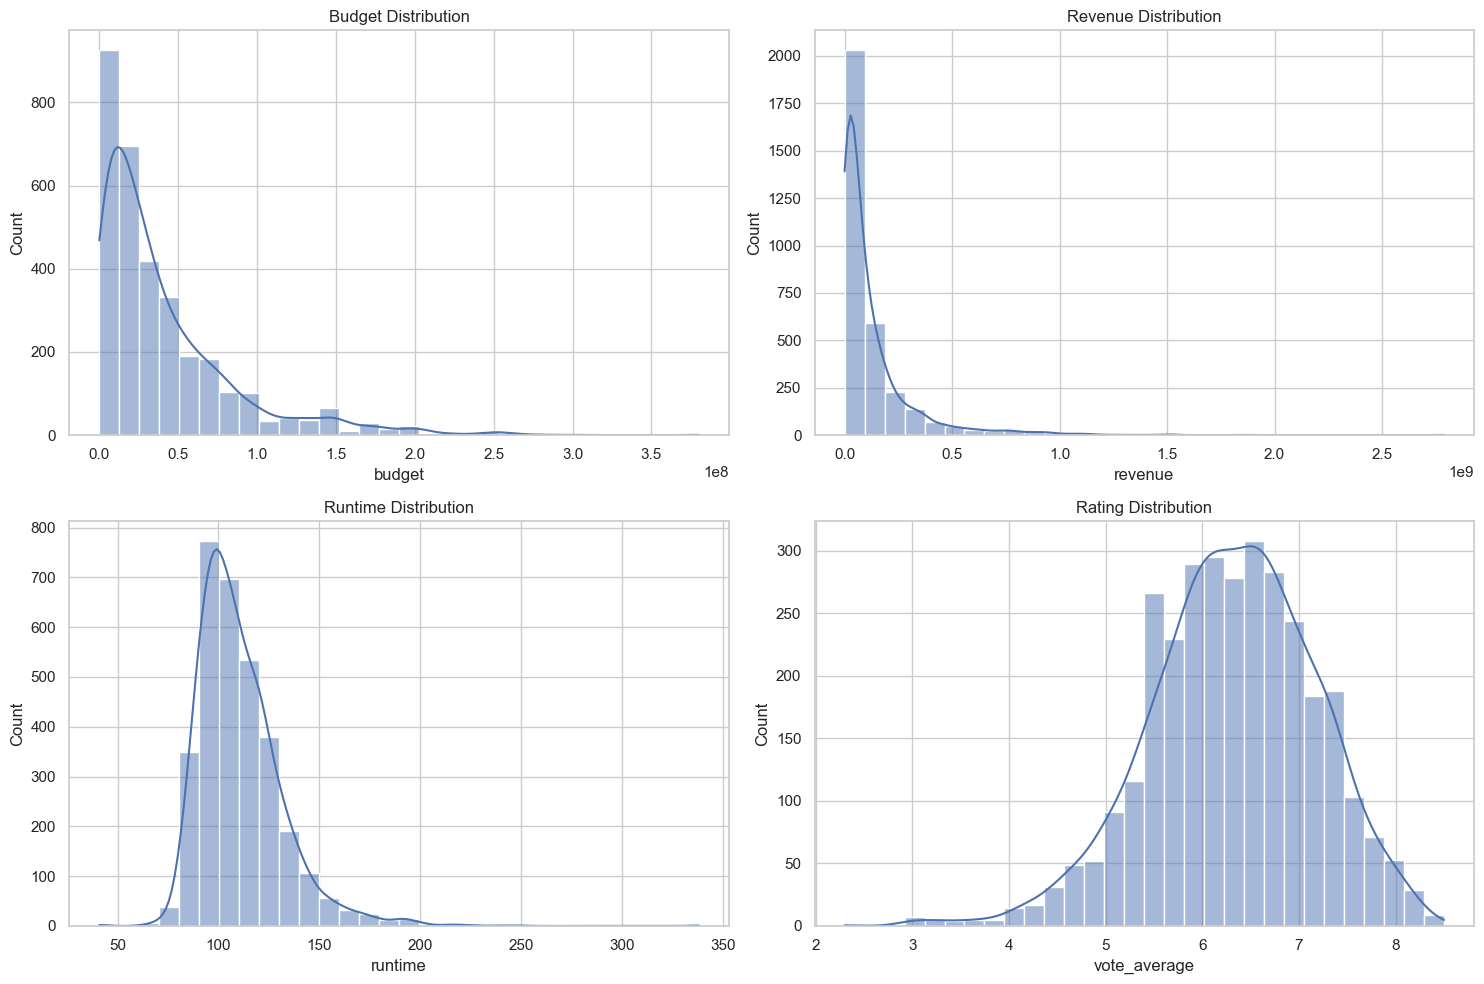

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df["budget"], bins=30, kde=True, ax=axes[0, 0]).set_title("Budget Distribution")
sns.histplot(df["revenue"], bins=30, kde=True, ax=axes[0, 1]).set_title("Revenue Distribution")
sns.histplot(df["runtime"].dropna(), bins=30, kde=True, ax=axes[1, 0]).set_title("Runtime Distribution")
sns.histplot(df["vote_average"], bins=30, kde=True, ax=axes[1, 1]).set_title("Rating Distribution")

plt.tight_layout()

plt.show()

## Boxplot

### Boxplot Budget
Il boxplot è compreso tra ~5M$ e ~50M$, con la mediana attorno ai 20–25M$. Il whisker superiore arriva a circa 120M$, ma la presenza di numerosi outlier fino a quasi 380M$ conferma la forte asimmetria già osservata nell'istogramma. Il 50% centrale dei film ha dunque un budget relativamente contenuto

### Boxplot Revenue
La distribuzione dei ricavi è ancora più compressa il boxplot è strettissimo tra ~0 e ~120M$, con la mediana vicinissima allo zero, a indicare che la metà dei film incassa pochissimo. Gli outlier sono però molto estremi, con un massimo isolato attorno a 2.7 miliardi di dollari. Il whisker superiore si ferma a ~350M$, e la nuvola di punti al di sopra rappresenta blockbuster eccezionali.

### Boxplot Runtime
La durata dei film è la variabile più compatta e simmetrica tra le quattro. Il boxplot va da circa 95 a 120 minuti, con la mediana intorno ai 110 minuti. Gli outlier superiori arrivano fino a ~330 minuti, mentre il valore minimo del whisker inferiore è circa 63 minuti. La scatola ristretta conferma che la maggior parte dei film rispetta la durata standard hollywoodiana.

### Boxplot Rating
Il boxplot dei voti medi è il più regolare e centrato. Il boxplot va da circa 5.8 a 6.8, con la mediana attorno a 6.3–6.4. I whisker si estendono da ~4.0 a ~8.0, mentre gli outlier bassi scendono fino a poco più di 2.

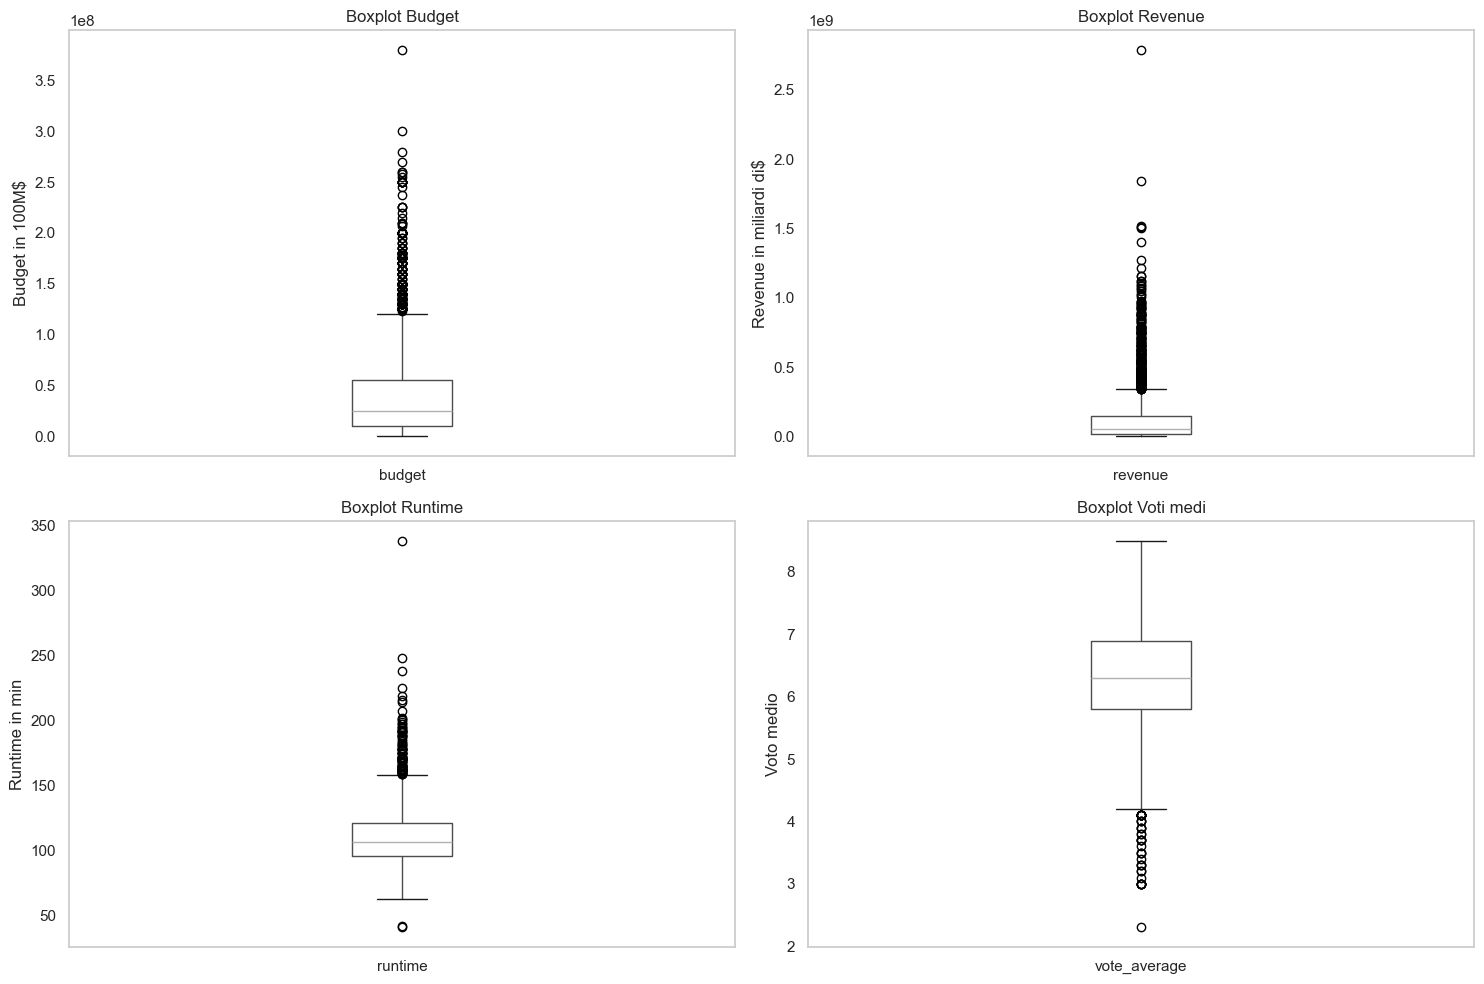

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

df.boxplot(column=["budget"], ax=axes[0], grid=False)
axes[0].set_title("Boxplot Budget")
axes[0].set_ylabel("Budget in 100M$")

df.boxplot(column=["revenue"], ax=axes[1], grid=False)
axes[1].set_title("Boxplot Revenue")
axes[1].set_ylabel("Revenue in miliardi di$")

df.boxplot(column=["runtime"], ax=axes[2], grid=False)
axes[2].set_title("Boxplot Runtime")
axes[2].set_ylabel("Runtime in min")

df.boxplot(column=["vote_average"], ax=axes[3], grid=False)
axes[3].set_title("Boxplot Voti medi")
axes[3].set_ylabel("Voto medio")

plt.tight_layout()
plt.show()

## Grafici a barre
Grazie ai grafici a barre possiamo vedere le frequenze categoriali del dataset, ovvero quante volte ciascuna categoria appare nel dataset. A differenza degli istogrammi classici, questi grafici operano su variabili categoriali, ordinate in modo decrescente per evidenziare immediatamente i valori dominanti.

### Top 10 generi
Il **Drama** è di gran lunga il genere più rappresentato, con 1441 film, seguito da **Comedy** (1110) e **Thriller** (935). **Action** occupa il quarto posto (918), mentre i generi meno rappresentati tra i top 10 sono **Family** (365) e **Fantasy** (342). Il distacco tra Drama e il resto suggerisce una netta dominanza di questo genere nel dataset.

### Top 10 Attori
**Robert De Niro** è in testa alla classifica degli attori con 45 film, staccando nettamente il secondo classificato **Bruce Willis** (35). Da lì in poi l'appiattimento della top 10 è abbastanza evidente con film che vanno da 35 a 29 film, formando un gruppo molto compatto.

### Top 10 Registi
**Steven Spielberg** è il regista più menzionato con 27 film, seguito da **Clint Eastwood** (19). **Martin Scorsese**, **Robert Rodriguez** e **Ridley Scott** sono raggruppati a 16 film. La classifica mostra registi con carriere molto prolifiche, tutti con un minimo di 13 film nel dataset.

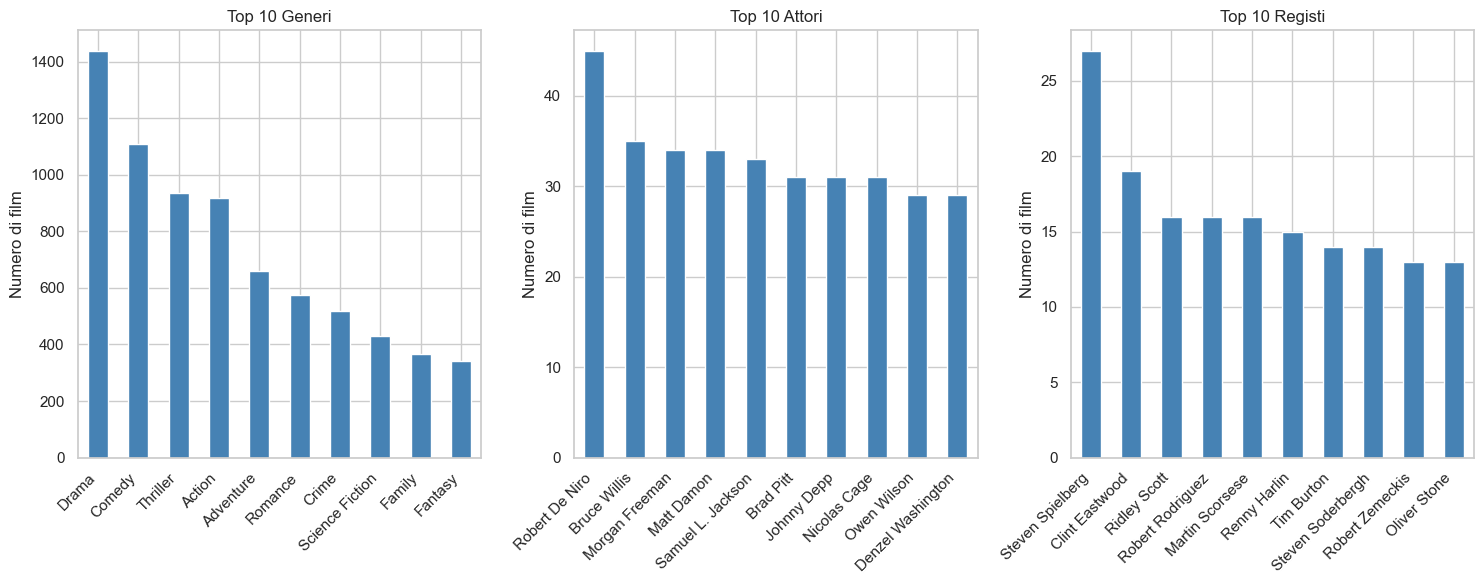

Generi totali: 19
Top 10 generi:
Drama              1438
Comedy             1110
Thriller            934
Action              918
Adventure           661
Romance             574
Crime               520
Science Fiction     431
Family              365
Fantasy             342
dtype: int64

Attori totali: 6153
Top 10 attori:
Robert De Niro       45
Bruce Willis         35
Morgan Freeman       34
Matt Damon           34
Samuel L. Jackson    33
Brad Pitt            31
Johnny Depp          31
Nicolas Cage         31
Owen Wilson          29
Denzel Washington    29
dtype: int64

Registi totali: 73
Top 10 registi:
Steven Spielberg     27
Clint Eastwood       19
Ridley Scott         16
Robert Rodriguez     16
Martin Scorsese      16
Renny Harlin         15
Tim Burton           14
Steven Soderbergh    14
Robert Zemeckis      13
Oliver Stone         13
dtype: int64


In [12]:
all_genres = [g for sublist in df["genres"] for g in sublist]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False).head(10)

all_cast = [g for sublist in df["cast"] for g in sublist]
cast_counts = pd.Series(Counter(all_cast)).sort_values(ascending=False).head(10)

director_counts = pd.Series(Counter(df["director"])).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
axes = axes.flatten()

genre_counts.plot(kind="bar", color="steelblue", ax=axes[0])
axes[0].set_title("Top 10 Generi")
axes[0].set_ylabel("Numero di film")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

cast_counts.plot(kind="bar", color="steelblue", ax=axes[1])
axes[1].set_title("Top 10 Attori")
axes[1].set_ylabel("Numero di film")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

director_counts.plot(kind="bar", color="steelblue", ax=axes[2])
axes[2].set_title("Top 10 Registi")
axes[2].set_ylabel("Numero di film")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

genres = {g for sublist in df["genres"] for g in sublist}
print(f"Generi totali: {len(genres)}")
print(f"Top 10 generi:\n{genre_counts}")

actors = {g for sublist in df["cast"] for g in sublist}
print(f"\nAttori totali: {len(actors)}")
print(f"Top 10 attori:\n{cast_counts}")

directors = {g for sublist in df["director"] for g in sublist}
print(f"\nRegisti totali: {len(directors)}")
print(f"Top 10 registi:\n{director_counts}")

### Top 10 generi per ROI
Il ritorno dell'investimento è un fattore importantissimo, e possiamo analizzare quali generi producono un maggior ROI tramite questo grafico a barre. Vediamo dunque che il genere **Documentary** è quello che frutta maggiormente, seguito da **Music** e **Horror**, nonostante non siano questi tra i più prodotti nel nostro dataset.

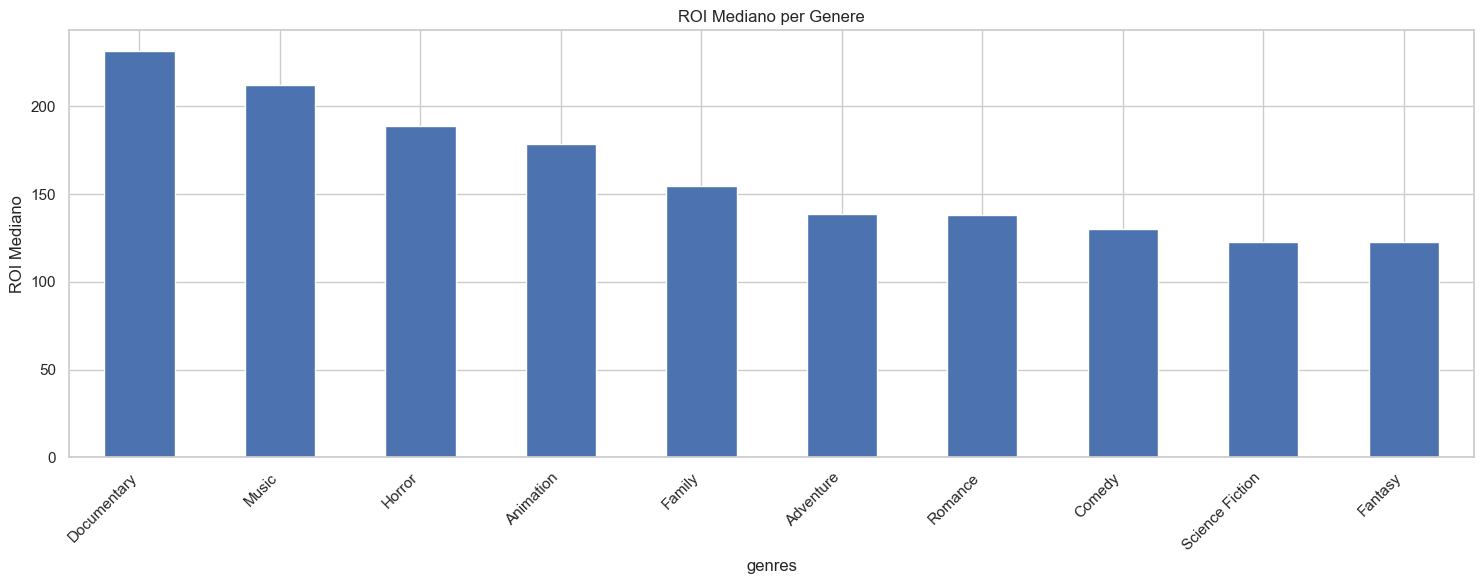

In [13]:
df_genres = df.explode("genres")
genre_roi = df_genres.groupby("genres")["roi"].median().sort_values(ascending=False).head(10)
genre_roi.plot(kind="bar", figsize=(15, 6), title="ROI Mediano per Genere")
plt.ylabel("ROI Mediano")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Top 10 film per revenue
Qui possiamo analizzare i film che hanno incassato maggiormente all'interno del nostro dataset, con **Avatar** al primo posto, seguito da **Titanic** e **The Avengers**, fino ad arrivare al decimo posto con **Captain America: Civil War**.

                          title     revenue  vote_average
0                        Avatar  2787965087           7.2
25                      Titanic  1845034188           7.5
16                 The Avengers  1519557910           7.4
28               Jurassic World  1513528810           6.5
44                    Furious 7  1506249360           7.3
7       Avengers: Age of Ultron  1405403694           7.3
123                      Frozen  1274219009           7.3
31                   Iron Man 3  1215439994           6.8
525                     Minions  1156730962           6.4
26   Captain America: Civil War  1153304495           7.1


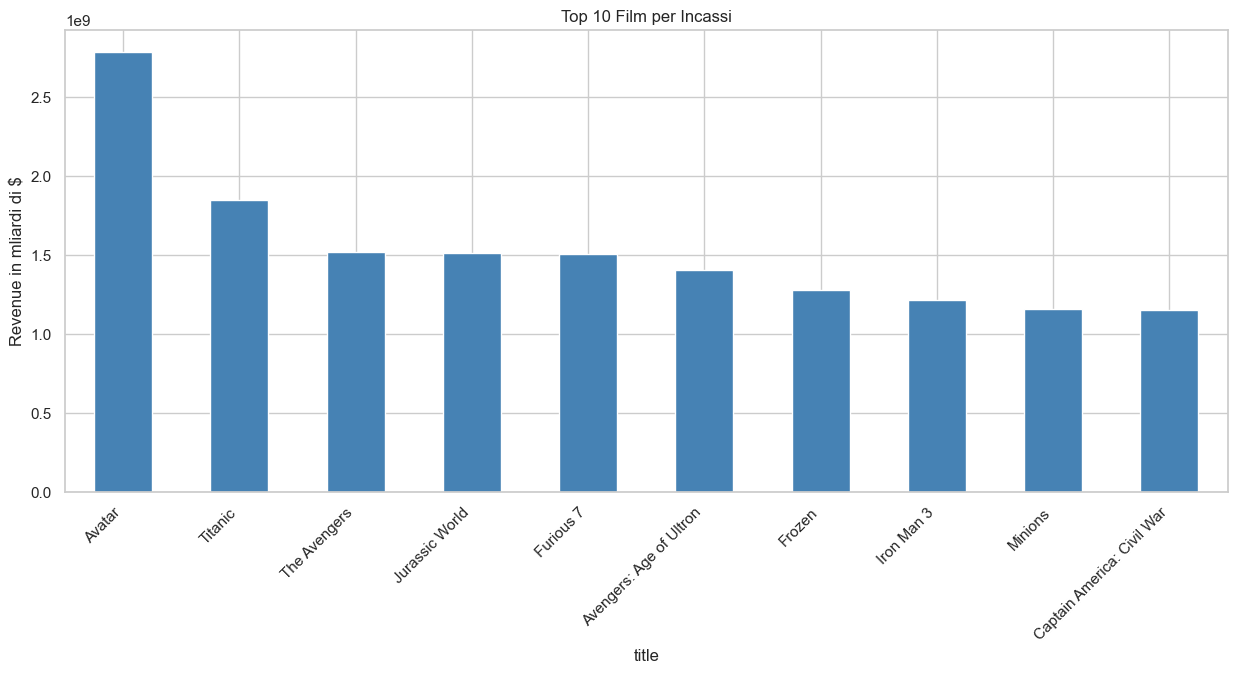

In [14]:
top10revenue = df.nlargest(10, "revenue")[["title", "revenue", "vote_average"]]
print(top10revenue)

top10revenue.plot(
    kind="bar",
    x="title",
    y="revenue",
    figsize=(15, 6),
    color="steelblue",
    title="Top 10 Film per Incassi",
    legend=False
)

plt.ylabel("Revenue in mliardi di $")
plt.xticks(rotation=45, ha="right") 
plt.show()

## Produzioni

### Cartogramma
Tramite questo grafico interattivo possiamo individuare i principali Paesi di produzione dei film presenti nel dataset. Qui possiamo notare un netto distacco degli **Stati Uniti d'America** con 2906 film, che si lascia molto dietro il secondo posto preso dal **Regno Unito** con 436 film. Da lì in poi i Paesi vanno sempre a calare in quanto a numero di produzione, compresa l'**Italia** che comunque si trova al sesto posto su 61 Paesi con 48 produzioni.

In [15]:
df_exploded = df.explode("production_countries")

df_map = df_exploded["production_countries"].value_counts().reset_index()
df_map.columns = ["Paese", "Numero Produzioni"]

fig = px.choropleth(
    df_map,
    locations="Paese",
    locationmode="country names",
    color="Numero Produzioni",
    hover_name="Paese",
    color_continuous_scale="Viridis",
    title="Produzioni per Paese"
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":25})

fig.show()

countries = {g for sublist in df["production_countries"] for g in sublist}
print(f"Paesi totali: {len(countries)}")
print(df_map.sort_values(by="Numero Produzioni", ascending=False)[:10])

/var/folders/v_/7f4h2tjn5dz_m_3fvd68j8nh0000gn/T/ipykernel_52617/2491699596.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Paesi totali: 61
                      Paese  Numero Produzioni
0  United States of America               2905
1            United Kingdom                436
2                   Germany                233
3                    France                196
4                    Canada                162
5                 Australia                 78
6                     Italy                 48
7                     Spain                 43
8                     Japan                 40
9                     China                 37


## Top 10 Aziende di Produzione
In questo grafico a barre possiamo notare, invece, le 10 più grandi Aziende di Produzione presenti all'interno del dataset. Nelle prime tre posizioni troviamo **Warner Bros.** con 280 film, **Universal Pictures** con 273 film e **Paramount Pictures** con 245 film. Da lì in poi la classifica va sempre più a calare ed appiattirsi arrivando alle ultime 4 posizioni tra i 100 e 92 film.

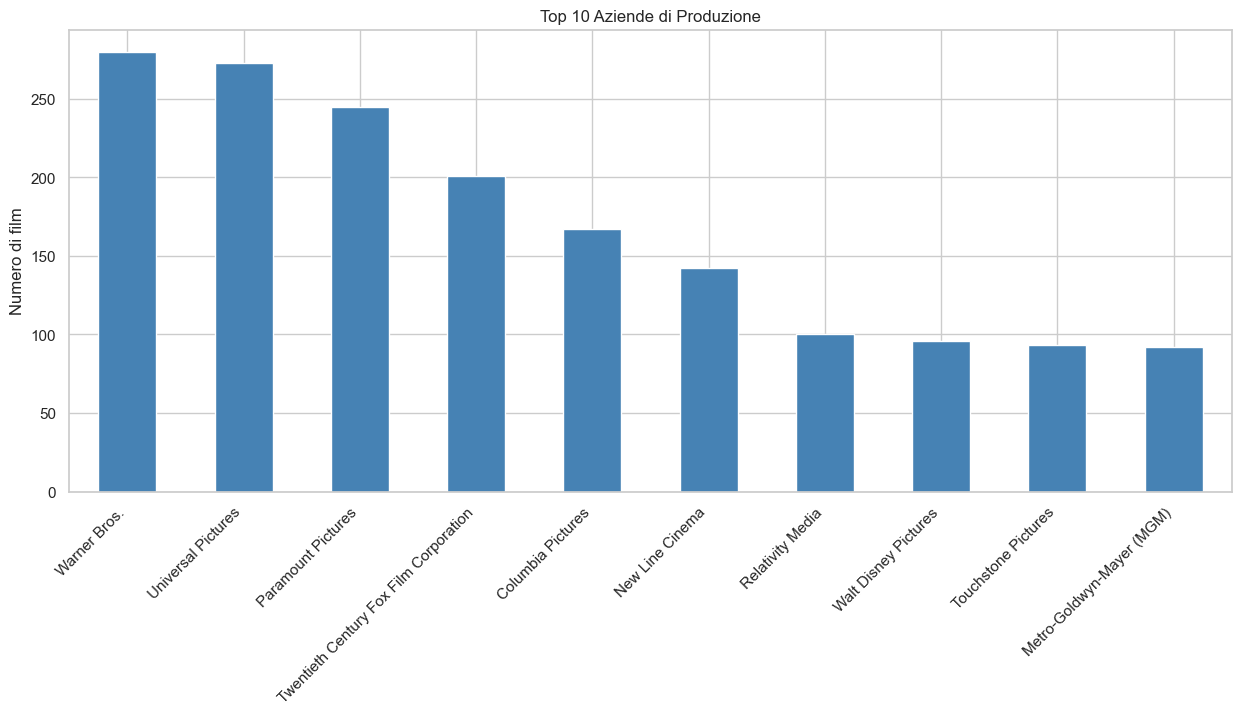

Paesi totali: 3562
Top 10 aziende:
Warner Bros.                              280
Universal Pictures                        273
Paramount Pictures                        245
Twentieth Century Fox Film Corporation    201
Columbia Pictures                         167
New Line Cinema                           142
Relativity Media                          100
Walt Disney Pictures                       96
Touchstone Pictures                        93
Metro-Goldwyn-Mayer (MGM)                  92
dtype: int64


In [16]:
all_companies = [g for sublist in df["production_companies"] for g in sublist]
companies_count = pd.Series(Counter(all_companies)).sort_values(ascending=False).head(10)

companies_count.plot(kind="bar", figsize=(15, 6), color="steelblue", title="Top 10 Aziende di Produzione")
plt.ylabel("Numero di film")
plt.xticks(rotation=45, ha="right") 
plt.show()

companies = {g for sublist in df["production_companies"] for g in sublist}
print(f"Paesi totali: {len(companies)}")
print(f"Top 10 aziende:\n{companies_count}")

## Relazioni numeriche
Questi due grafici analizzano le relazioni tra le variabili numeriche del dataset: la matrice di correlazione fornisce una visione globale delle dipendenze lineari, mentre lo scatter plot approfondisce il rapporto specifico tra budget e revenue.

### Matrice di Correlazione
La matrice riporta i coefficienti di correlazione di Pearson tra le variabili `budget`, `revenue`, `popularity`, `vote_average`, `runtime` e `roi`. Le correlazioni più rilevanti sono:
- `budget` e `revenue`: 0.71, correlazione positiva forte, quindi i film con budget più alto tendono a incassare di più
- `revenue` e `popularity`: 0.60, i film più popolari generano ricavi maggiori
- `budget` e `popularity`: 0.43, correlazione moderata, film costosi sono generalmente più noti
- `runtime` e `vote_average`: 0.39, i film più lunghi tendono ad avere voti leggermente più alti
- `vote_average` e `budget`: -0.04, correlazione praticamente nulla, quindi spendere di più non garantisce un voto migliore
- `roi`: praticamente incorrelato con tutte le variabili, suggerendo che il ritorno sull'investimento dipende da fattori non lineari o non presenti nel dataset

### Scatter Plot Budget vs Revenue
Il grafico mostra la relazione diretta tra `budget` e `revenue`, con i punti colorati in base al `vote_average`. Si osserva una certa tendenza positiva all'aumentare del budget cresce mediamente anche la revenue, ma con una dispersione molto elevata, specialmente nella fascia 0–100M$ di budget dove i risultati sono estremamente variabili. I film con `vote_average` più alto (punti giallo-verdi) tendono a concentrarsi nelle fasce di budget medio-alte, e alcuni di questi sono outlier con revenue superiore a 2.5 miliardi.

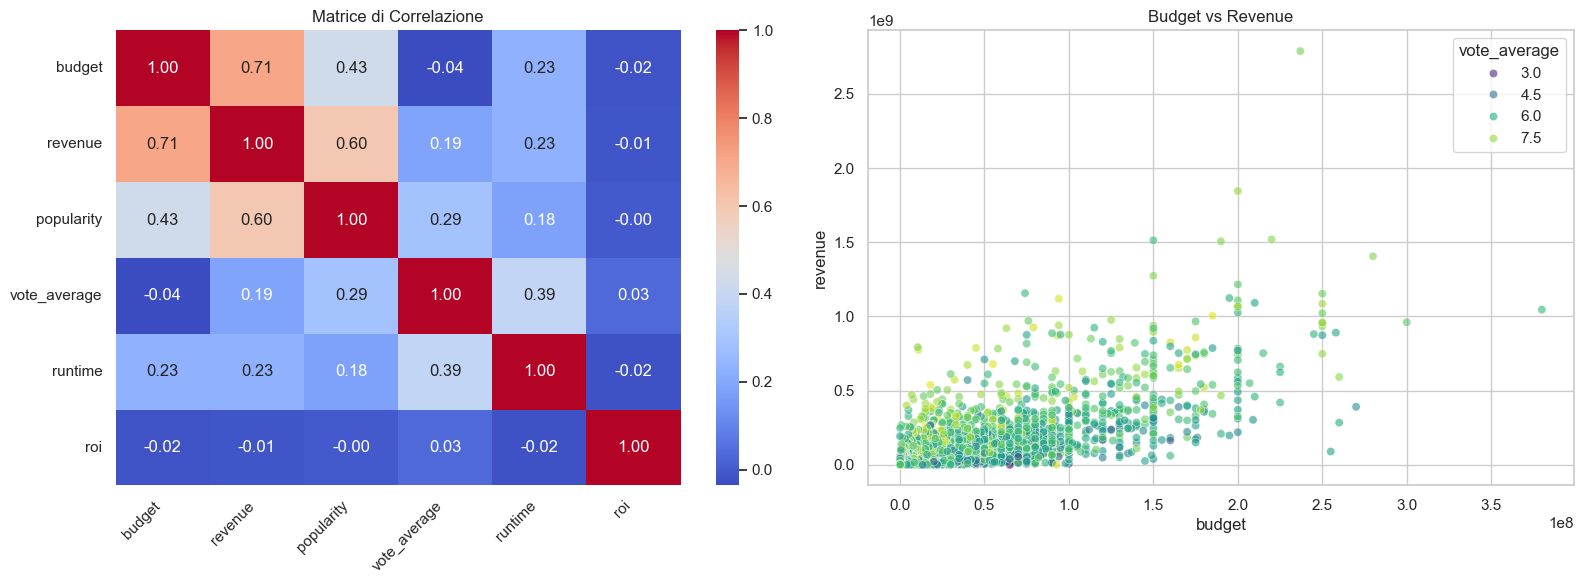

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df[["budget", "revenue", "popularity", "vote_average", "runtime", "roi"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Matrice di Correlazione")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

sns.scatterplot(data=df, x="budget", y="revenue", hue="vote_average", palette="viridis", alpha=0.6, ax=axes[1])
axes[1].set_title("Budget vs Revenue")

plt.tight_layout()
plt.show()

### Film prodotti per anno
Grazie a questo grafico a linee possiamo analizzare le tendenze di produzione annuali dei film presenti nel dataset, che vedono gli anni di produzione schizzare tra gli anni '90 ed il 2000 con il picco di produzione raggiunto intorno al 2010/2015. Tuttavia, dopo il 2000, la linea diventa molto più irregolare, indicando forti variazioni annuali nella produzione rispetto alla stabilità dei decenni precedenti. Intorno al 2017 abbiamo un calo drastico della produzione, questo calo drastico non indica necessariamente un collasso dell'industria cinematografica, ma è quasi certamente dovuto a un limite del dataset.

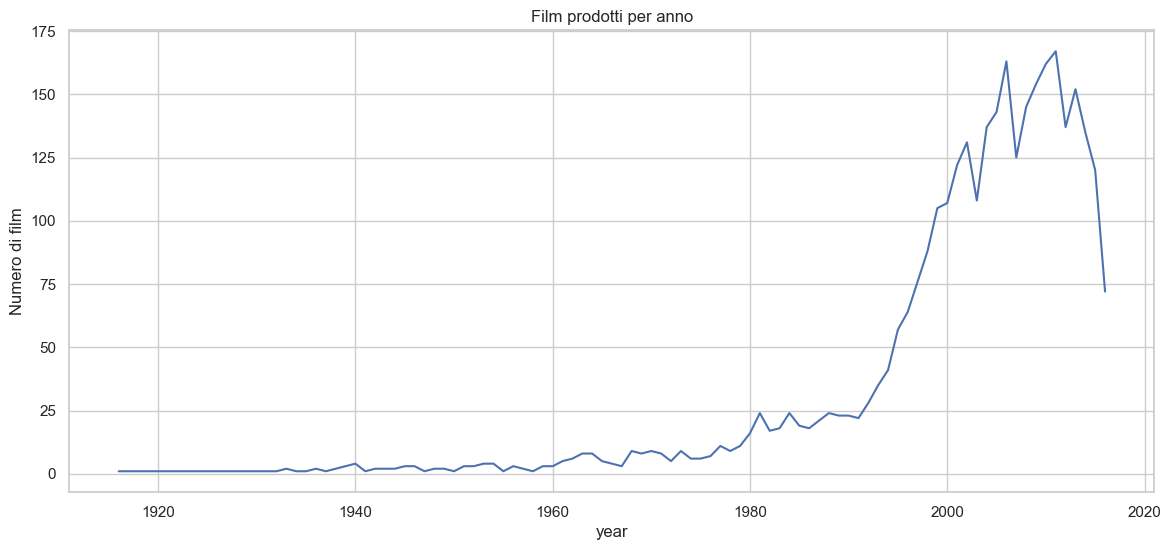

In [18]:
films_per_year = df.groupby("year").size()
films_per_year.plot(figsize=(14, 6), title="Film prodotti per anno")
plt.ylabel("Numero di film")
plt.show()